In [3]:
 # ============================================================
# NB4 · Cell 1 — Setup, paths, load both checkpoints
# ============================================================
import os, sys, json, random, time
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# GPU check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
print()

# --- Find both checkpoints anywhere under /kaggle/input/ ---
def find_file(filename, search_root="/kaggle/input"):
    for root, dirs, files in os.walk(search_root):
        if filename in files:
            return os.path.join(root, filename)
    return None

resnet_ckpt = find_file("resnet50_best.pt")
swin_ckpt   = find_file("swin_t_best.pt")
print("Checkpoints:")
print(f"  ResNet50 : {resnet_ckpt or '❌ NOT FOUND'}")
print(f"  Swin-T   : {swin_ckpt or '❌ NOT FOUND'}")

# --- Find PlantDoc maize folders (case-insensitive 'corn' or 'maize', excludes PlantVillage) ---
print("\nSearching for PlantDoc maize folders...")
plantdoc_dirs = []
for root, dirs, files in os.walk("/kaggle/input"):
    name = os.path.basename(root).lower()
    if any(t in name for t in ["corn", "maize"]):
        n = sum(1 for f in files if f.lower().endswith((".jpg", ".jpeg", ".png")))
        # Exclude PlantVillage paths so we only see PlantDoc folders
        if n > 0 and "plantvillage" not in root.lower() and "abdallahalidev" not in root.lower():
            plantdoc_dirs.append((root, n))

print(f"\nFound {len(plantdoc_dirs)} PlantDoc-style maize folders:")
for path, n in sorted(plantdoc_dirs):
    print(f"  {n:>4} images  {path}")

# --- Build both models in memory with NB1/NB2 weights ---
print("\nBuilding ResNet50...")
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(resnet50.fc.in_features, 4)
)
if resnet_ckpt:
    resnet50.load_state_dict(torch.load(resnet_ckpt, map_location=device))
    resnet50 = resnet50.to(device).eval()
    print("  ✅ Loaded NB1 ResNet50 weights")
else:
    print("  ⚠️  ResNet50 checkpoint not found — zero-shot eval will skip ResNet50")

print("\nBuilding Swin-T...")
swin = models.swin_t(weights=None)
swin.head = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(swin.head.in_features, 4)
)
if swin_ckpt:
    swin.load_state_dict(torch.load(swin_ckpt, map_location=device))
    swin = swin.to(device).eval()
    print("  ✅ Loaded NB2 Swin-T weights")
else:
    print("  ❌ Swin-T checkpoint not found — required for NB4")
    raise FileNotFoundError("swin_t_best.pt not found")

# --- Sanity check ---
with torch.no_grad():
    x_dummy = torch.randn(2, 3, 224, 224, device=device)
    if resnet_ckpt:
        print(f"\nResNet50 forward: {tuple(x_dummy.shape)} → {tuple(resnet50(x_dummy).shape)}")
    print(f"Swin-T   forward: {tuple(x_dummy.shape)} → {tuple(swin(x_dummy).shape)}")

print("\nCell 1 complete ✅")

Device : cuda
GPU    : Tesla T4

Checkpoints:
  ResNet50 : /kaggle/input/datasets/aproton/outputfrom1/resnet50_best.pt
  Swin-T   : /kaggle/input/datasets/aproton/nb2-output/swin_t_best.pt

Searching for PlantDoc maize folders...

Found 6 PlantDoc-style maize folders:
     4 images  /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Corn_Gray_leaf_spot
    12 images  /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Corn_leaf_blight
    10 images  /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/test/Corn_rust_leaf
    63 images  /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/train/Corn_Gray_leaf_spot
   182 images  /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/train/Corn_leaf_blight
   107 images  /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset/train/Corn_rust_leaf

Building ResNet50...
  ✅ Loaded NB1 ResNet50 weights

Building Swin-T...
  ✅ Loaded NB2 Swin-T weights

ResNet50 forward: (2, 3, 224, 224) → (2, 4)
Swin-T   forward: (

In [4]:
# ============================================================
# NB4 · Cell 2 — Build PlantDoc dataset + zero-shot evaluation
# ============================================================

# --- Class mapping: PlantDoc folder name → our 4-class indexing (from NB1/NB2) ---
# Our class order (alphabetical, set during NB1):
#   0: Gray Leaf Spot   1: Common Rust   2: Northern Leaf Blight   3: Healthy
DISPLAY_NAMES = ["Gray Leaf Spot", "Common Rust", "Northern Leaf Blight", "Healthy"]

PLANTDOC_TO_OUR_CLASS = {
    "Corn_Gray_leaf_spot": 0,   # → Gray Leaf Spot
    "Corn_rust_leaf":      1,   # → Common Rust
    "Corn_leaf_blight":    2,   # → Northern Leaf Blight
    # PlantDoc has no Healthy corn class — class 3 won't appear in ground truth
}

# --- Build dataset: combine PlantDoc train+test (all unseen by our model) ---
PLANTDOC_ROOT = "/kaggle/input/datasets/nirmalsankalana/plantdoc-dataset"
plantdoc_paths, plantdoc_labels = [], []
for split in ["train", "test"]:
    for folder_name, class_idx in PLANTDOC_TO_OUR_CLASS.items():
        folder = os.path.join(PLANTDOC_ROOT, split, folder_name)
        if not os.path.isdir(folder):
            continue
        for img in os.listdir(folder):
            if img.lower().endswith((".jpg", ".jpeg", ".png")):
                plantdoc_paths.append(os.path.join(folder, img))
                plantdoc_labels.append(class_idx)

print(f"Total PlantDoc maize images: {len(plantdoc_paths)}")
print("\nClass distribution (mapped to our 4-class indexing):")
counts = Counter(plantdoc_labels)
for c in range(4):
    n = counts.get(c, 0)
    note = " — not in PlantDoc, won't appear" if c == 3 else ""
    print(f"  Class {c} ({DISPLAY_NAMES[c]:<22}): {n:>4} images{note}")

# --- Eval transform (same as NB1/NB2) ---
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
eval_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class PlantDocDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = paths, labels, tfm
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tfm(img), self.labels[i]

plantdoc_ds     = PlantDocDataset(plantdoc_paths, plantdoc_labels, eval_tfm)
plantdoc_loader = DataLoader(plantdoc_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

# --- Zero-shot evaluation function ---
@torch.no_grad()
def zero_shot_eval(model, loader, device):
    """Run model on PlantDoc, returning preds + labels + metrics."""
    model.eval()
    preds, labs = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        labs.extend(y.numpy())
    preds, labs = np.array(preds), np.array(labs)
    acc = float((preds == labs).mean())
    # Macro F1 over the 3 disease classes (label 3=Healthy doesn't appear in ground truth)
    f1  = float(f1_score(labs, preds, labels=[0, 1, 2], average="macro"))
    return preds, labs, acc, f1

print("\n" + "=" * 70)
print("ZERO-SHOT EVALUATION on PlantDoc — NO adaptation, NO fine-tuning")
print("=" * 70)

# --- ResNet50 ---
print("\n▶ ResNet50 (NB1 weights, trained on PlantVillage lab images):")
rn_preds, rn_labs, rn_acc, rn_f1 = zero_shot_eval(resnet50, plantdoc_loader, device)
print(f"  PlantDoc accuracy : {rn_acc:.4f}")
print(f"  PlantDoc macro F1 : {rn_f1:.4f}  (over 3 disease classes)")
print("  Per-class recall (% correct of true class):")
for c in [0, 1, 2]:
    mask = rn_labs == c
    if mask.sum() > 0:
        cls_acc = (rn_preds[mask] == c).mean()
        print(f"    {DISPLAY_NAMES[c]:<22}: {cls_acc*100:5.1f}%  ({(rn_preds[mask] == c).sum()}/{mask.sum()})")
print("  Prediction distribution (where the model thinks PlantDoc images belong):")
pred_counts = Counter(rn_preds.tolist())
for c in range(4):
    pct = 100 * pred_counts.get(c, 0) / len(rn_preds)
    note = " ← false positives, no Healthy in ground truth!" if c == 3 and pred_counts.get(3, 0) > 0 else ""
    print(f"    {DISPLAY_NAMES[c]:<22}: {pred_counts.get(c, 0):>4} ({pct:.0f}%){note}")

# --- Swin-T ---
print("\n▶ Swin-T (NB2 weights, trained on PlantVillage lab images):")
sw_preds, sw_labs, sw_acc, sw_f1 = zero_shot_eval(swin, plantdoc_loader, device)
print(f"  PlantDoc accuracy : {sw_acc:.4f}")
print(f"  PlantDoc macro F1 : {sw_f1:.4f}  (over 3 disease classes)")
print("  Per-class recall:")
for c in [0, 1, 2]:
    mask = sw_labs == c
    if mask.sum() > 0:
        cls_acc = (sw_preds[mask] == c).mean()
        print(f"    {DISPLAY_NAMES[c]:<22}: {cls_acc*100:5.1f}%  ({(sw_preds[mask] == c).sum()}/{mask.sum()})")
print("  Prediction distribution:")
pred_counts = Counter(sw_preds.tolist())
for c in range(4):
    pct = 100 * pred_counts.get(c, 0) / len(sw_preds)
    note = " ← false positives" if c == 3 and pred_counts.get(3, 0) > 0 else ""
    print(f"    {DISPLAY_NAMES[c]:<22}: {pred_counts.get(c, 0):>4} ({pct:.0f}%){note}")

# --- The domain gap headline ---
PV_RN_ACC, PV_SW_ACC = 0.9792, 0.9827
PV_RN_F1,  PV_SW_F1  = 0.9698, 0.9752

print("\n" + "=" * 76)
print("DOMAIN GAP — PlantVillage (lab) vs PlantDoc (real-world field)")
print("=" * 76)
print(f"{'Model':<12}{'PV Accuracy':>14}{'PD Accuracy':>14}{'Drop':>14}")
print("-" * 76)
print(f"{'ResNet50':<12}{PV_RN_ACC:>14.4f}{rn_acc:>14.4f}{rn_acc - PV_RN_ACC:>+14.4f}")
print(f"{'Swin-T':<12}{PV_SW_ACC:>14.4f}{sw_acc:>14.4f}{sw_acc - PV_SW_ACC:>+14.4f}")
print()
print(f"{'Model':<12}{'PV Macro F1':>14}{'PD Macro F1':>14}{'Drop':>14}")
print("-" * 76)
print(f"{'ResNet50':<12}{PV_RN_F1:>14.4f}{rn_f1:>14.4f}{rn_f1 - PV_RN_F1:>+14.4f}")
print(f"{'Swin-T':<12}{PV_SW_F1:>14.4f}{sw_f1:>14.4f}{sw_f1 - PV_SW_F1:>+14.4f}")
print("=" * 76)

# --- Stash for Cell 4 ---
zero_shot_results = {
    "n_plantdoc_images": len(plantdoc_paths),
    "resnet50": {"accuracy": rn_acc, "macro_f1": rn_f1,
                 "preds": rn_preds.tolist(), "labels": rn_labs.tolist()},
    "swin_t":   {"accuracy": sw_acc, "macro_f1": sw_f1,
                 "preds": sw_preds.tolist(), "labels": sw_labs.tolist()},
}

print("\nCell 2 complete ✅")

Total PlantDoc maize images: 378

Class distribution (mapped to our 4-class indexing):
  Class 0 (Gray Leaf Spot        ):   67 images
  Class 1 (Common Rust           ):  117 images
  Class 2 (Northern Leaf Blight  ):  194 images
  Class 3 (Healthy               ):    0 images — not in PlantDoc, won't appear

ZERO-SHOT EVALUATION on PlantDoc — NO adaptation, NO fine-tuning

▶ ResNet50 (NB1 weights, trained on PlantVillage lab images):
  PlantDoc accuracy : 0.2381
  PlantDoc macro F1 : 0.2313  (over 3 disease classes)
  Per-class recall (% correct of true class):
    Gray Leaf Spot        :  50.7%  (34/67)
    Common Rust           :   3.4%  (4/117)
    Northern Leaf Blight  :  26.8%  (52/194)
  Prediction distribution (where the model thinks PlantDoc images belong):
    Gray Leaf Spot        :  190 (50%)
    Common Rust           :    5 (1%)
    Northern Leaf Blight  :   92 (24%)
    Healthy               :   91 (24%) ← false positives, no Healthy in ground truth!

▶ Swin-T (NB2 weigh

In [5]:
# ============================================================
# NB4 · Cell 3 — Few-shot adaptation on PlantDoc with Swin-T features
# ============================================================

# --- Extract Swin-T embeddings for ALL PlantDoc images ---
@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    feats_all, labels_all = [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        f = model.features(x); f = model.norm(f)
        f = model.permute(f); f = model.avgpool(f); f = model.flatten(f)
        feats_all.append(f.cpu()); labels_all.append(y)
    return torch.cat(feats_all, dim=0), torch.cat(labels_all, dim=0)

print("Extracting Swin-T embeddings for all PlantDoc images...")
t0 = time.time()
pd_embeddings, pd_labels = extract_embeddings(swin, plantdoc_loader, device)
print(f"Embeddings shape: {tuple(pd_embeddings.shape)}   [{time.time()-t0:.1f}s]")

# Group embeddings by class (only 3 disease classes in PlantDoc)
pd_embeddings_by_class = {}
print("\nEmbeddings per class:")
for c in [0, 1, 2]:
    mask = pd_labels == c
    pd_embeddings_by_class[c] = pd_embeddings[mask]
    print(f"  {DISPLAY_NAMES[c]:<22}: {pd_embeddings_by_class[c].shape[0]} embeddings")

# Sanity check — how separable are PlantDoc embeddings?
intra, inter = [], []
for c in [0, 1, 2]:
    cls = pd_embeddings_by_class[c]
    if len(cls) > 1:
        i1, i2 = torch.randint(0, len(cls), (50,)), torch.randint(0, len(cls), (50,))
        intra.append((cls[i1] - cls[i2]).pow(2).sum(dim=1).sqrt().mean().item())
    other = torch.cat([pd_embeddings_by_class[k] for k in [0, 1, 2] if k != c])
    i1, i2 = torch.randint(0, len(cls), (50,)), torch.randint(0, len(other), (50,))
    inter.append((cls[i1] - other[i2]).pow(2).sum(dim=1).sqrt().mean().item())

ratio_pd = np.mean(inter) / np.mean(intra)
print(f"\nClustering on PlantDoc:  inter/intra ratio = {ratio_pd:.2f}")
print(f"  (For comparison, PlantVillage ratio was 1.62)")

# --- Episodic eval (same machinery as NB3, adapted for 3-way) ---
def sample_episode(embeddings_by_class, n_way, k_shot, n_query, rng):
    classes  = sorted(embeddings_by_class.keys())
    selected = rng.choice(classes, size=n_way, replace=False)
    s_embs, s_labs, q_embs, q_labs = [], [], [], []
    for new_lab, orig_class in enumerate(selected):
        cls_embs = embeddings_by_class[int(orig_class)]
        idx = rng.permutation(len(cls_embs))[:k_shot + n_query]
        s_embs.append(cls_embs[idx[:k_shot]])
        q_embs.append(cls_embs[idx[k_shot:k_shot + n_query]])
        s_labs.extend([new_lab] * k_shot)
        q_labs.extend([new_lab] * n_query)
    return torch.cat(s_embs), torch.tensor(s_labs), torch.cat(q_embs), torch.tensor(q_labs)

def prototypical_classify(s_embs, s_labs, q_embs, n_way, distance, normalize):
    if normalize:
        s_embs = F.normalize(s_embs, dim=1)
        q_embs = F.normalize(q_embs, dim=1)
    prototypes = torch.stack([s_embs[s_labs == c].mean(dim=0) for c in range(n_way)])
    if distance == "euclidean":
        dists = torch.cdist(q_embs, prototypes, p=2)
    else:
        dists = 1.0 - q_embs @ prototypes.T
    return dists.argmin(dim=1)

def run_episodes(embeddings_by_class, n_way, k_shot, n_query, n_episodes,
                 distance="euclidean", normalize=False, seed=42):
    rng = np.random.RandomState(seed)
    accs = np.empty(n_episodes, dtype=np.float32)
    for i in range(n_episodes):
        s_embs, s_labs, q_embs, q_labs = sample_episode(
            embeddings_by_class, n_way, k_shot, n_query, rng)
        preds = prototypical_classify(s_embs, s_labs, q_embs, n_way, distance, normalize)
        accs[i] = (preds == q_labs).float().mean().item()
    return float(accs.mean()), float(1.96 * accs.std() / np.sqrt(n_episodes)), accs

# --- Run 1000 episodes per setting ---
N_WAY      = 3      # PlantDoc has 3 disease classes
N_QUERY    = 15
N_EPISODES = 1000

print(f"\nProtocol: {N_WAY}-way K-shot · {N_QUERY} queries per class · {N_EPISODES} episodes\n")

settings = [
    ("Euclidean (raw)",        "euclidean", False),
    ("Cosine (L2-normalized)", "cosine",    True),
]
fewshot_results = {}

for k_shot in [1, 5]:
    print(f"--- {N_WAY}-way {k_shot}-shot ---")
    for label, dist, norm in settings:
        t0 = time.time()
        mean_acc, ci95, accs = run_episodes(
            pd_embeddings_by_class, N_WAY, k_shot, N_QUERY, N_EPISODES,
            distance=dist, normalize=norm, seed=SEED + k_shot)
        elapsed = time.time() - t0
        print(f"  {label:<26}: {mean_acc*100:6.2f}% ± {ci95*100:.2f}%   [{elapsed:.1f}s]")
        fewshot_results[f"{N_WAY}way_{k_shot}shot_{dist}{'_norm' if norm else ''}"] = {
            "n_way": N_WAY, "k_shot": k_shot, "n_query": N_QUERY,
            "distance": dist, "normalize": norm,
            "mean_accuracy": mean_acc, "ci95": ci95,
            "all_accuracies": accs.tolist()
        }
    print()

# --- Headline summary: zero-shot vs few-shot recovery ---
print("=" * 78)
print("PAPER TABLE — Domain gap and few-shot recovery (PlantDoc 3-class)")
print("=" * 78)
print(f"{'Method':<48}{'Accuracy':>13}{'Labels used':>15}")
print("-" * 78)
print(f"{'Swin-T (PlantVillage test, in-domain)':<48}{'98.27%':>13}{'2696':>15}")
print(f"{'ResNet50 (PlantVillage test, in-domain)':<48}{'97.92%':>13}{'2696':>15}")
print(f"{'Swin-T zero-shot on PlantDoc':<48}{sw_acc*100:>12.2f}%{'0':>15}")
print(f"{'ResNet50 zero-shot on PlantDoc':<48}{rn_acc*100:>12.2f}%{'0':>15}")
for k_shot in [1, 5]:
    best_key = max([k for k in fewshot_results if f"_{k_shot}shot_" in k],
                   key=lambda k: fewshot_results[k]["mean_accuracy"])
    r = fewshot_results[best_key]
    name = f"3-way {k_shot}-shot ProtoNet on PlantDoc (best: {r['distance']}{'+norm' if r['normalize'] else ''})"
    print(f"{name:<48}{r['mean_accuracy']*100:>12.2f}%{k_shot * N_WAY:>15}")
print("=" * 78)

# --- Recovery percentage (the publishable claim) ---
swin_drop  = PV_SW_ACC - sw_acc                           # how much Swin-T lost
best_5shot = max(r["mean_accuracy"] for k, r in fewshot_results.items() if "5shot" in k)
recovered  = (best_5shot - sw_acc) / swin_drop * 100      # what % of the gap we close
print(f"\nFew-shot recovery analysis (Swin-T baseline):")
print(f"  Domain gap (PV → PD)         : {swin_drop*100:.1f} percentage points lost")
print(f"  5-shot recovery on PlantDoc  : {best_5shot*100:.2f}%")
print(f"  Gap closed by 5 labels/class : {recovered:.0f}%  (the headline claim)")

print("\nCell 3 complete ✅")

Extracting Swin-T embeddings for all PlantDoc images...
Embeddings shape: (378, 768)   [9.8s]

Embeddings per class:
  Gray Leaf Spot        : 67 embeddings
  Common Rust           : 117 embeddings
  Northern Leaf Blight  : 194 embeddings

Clustering on PlantDoc:  inter/intra ratio = 1.03
  (For comparison, PlantVillage ratio was 1.62)

Protocol: 3-way K-shot · 15 queries per class · 1000 episodes

--- 3-way 1-shot ---
  Euclidean (raw)           :  40.11% ± 0.49%   [0.8s]
  Cosine (L2-normalized)    :  41.57% ± 0.54%   [0.8s]

--- 3-way 5-shot ---
  Euclidean (raw)           :  51.02% ± 0.50%   [0.9s]
  Cosine (L2-normalized)    :  49.72% ± 0.49%   [0.8s]

PAPER TABLE — Domain gap and few-shot recovery (PlantDoc 3-class)
Method                                               Accuracy    Labels used
------------------------------------------------------------------------------
Swin-T (PlantVillage test, in-domain)                  98.27%           2696
ResNet50 (PlantVillage test, in-dom

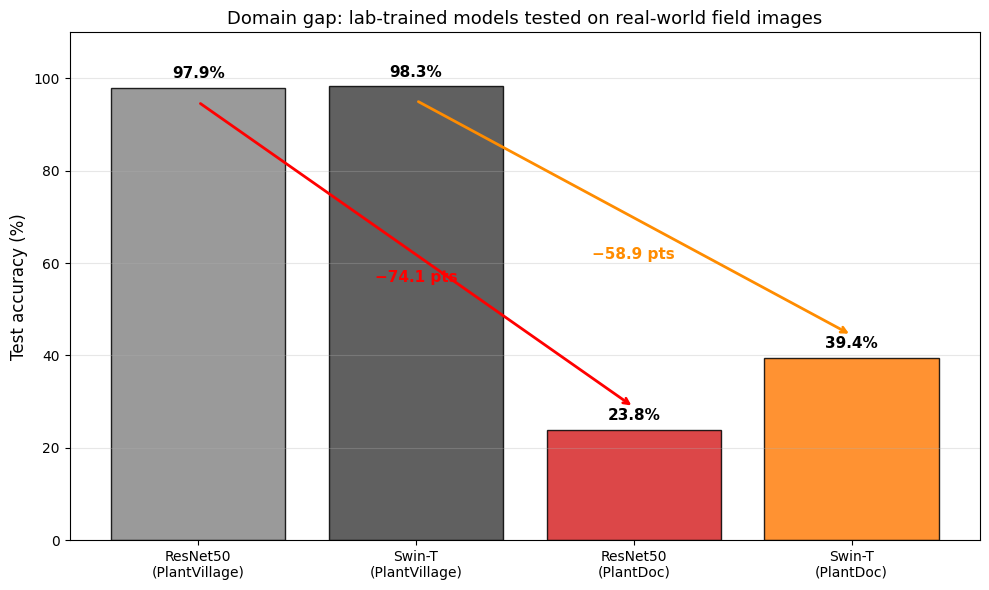

Saved: /kaggle/working/nb4_domain_gap.png


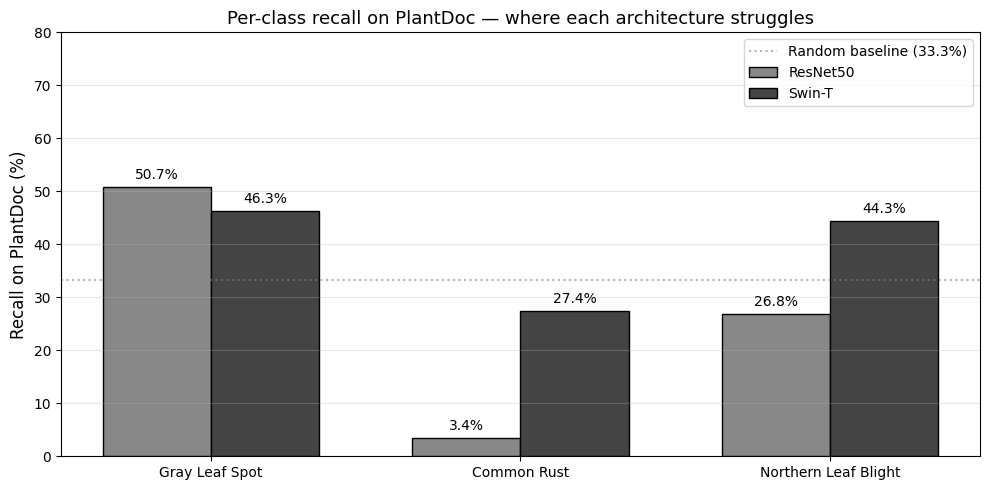

Saved: /kaggle/working/nb4_per_class_recall.png


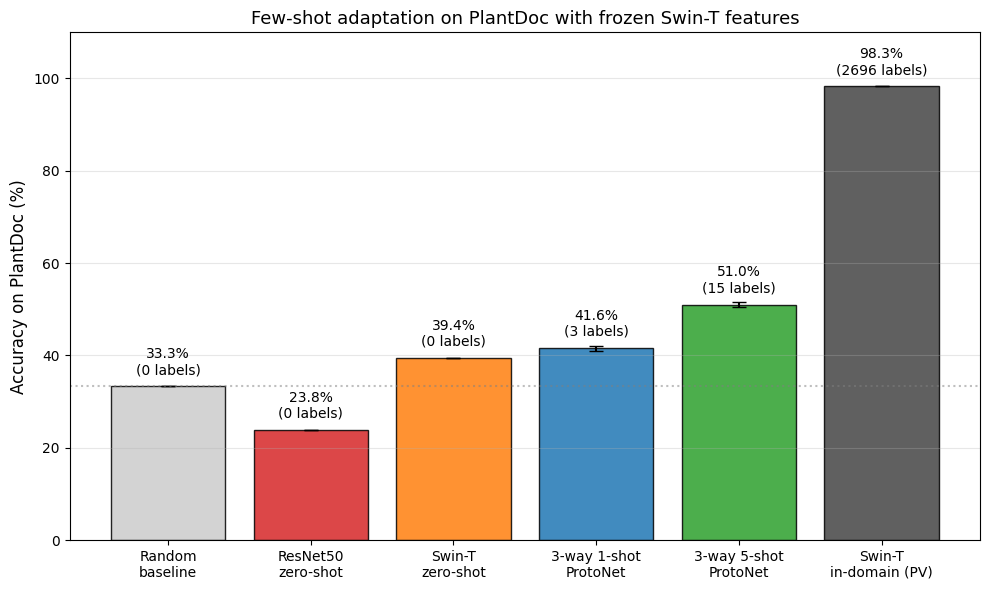

Saved: /kaggle/working/nb4_fewshot_recovery.png
Saved: /kaggle/working/nb4_domain_gap_results.json

NB4 — FINAL SUMMARY
  • ResNet50 drops 74.1 pts (lab→field), Swin-T drops 58.9 pts
  • Swin-T's smaller drop (58.9 vs 74.1 pts) suggests attention generalizes better than CNN inductive biases
  • Both models show false-positive 'Healthy' predictions on diseased field images — a deployment-risk concern
  • ProtoNet on frozen Swin-T features improves over zero-shot but plateaus around 51%, confirming Chen et al. 2019 finding that severe domain shift requires feature adaptation, not just classifier change

Setting                                            Accuracy         Labels
------------------------------------------------------------------------------
In-domain Swin-T (PlantVillage test)                 98.27%           2696
In-domain ResNet50 (PlantVillage test)               97.92%           2696
PlantDoc Swin-T zero-shot                            39.42%              0
PlantDoc Res

In [6]:
# ============================================================
# NB4 · Cell 4 — Comparison figures + save final results
# ============================================================

# --- Aggregate the headline numbers ---
PV_RN_ACC, PV_SW_ACC = 0.9792, 0.9827
PD_RN_ACC, PD_SW_ACC = rn_acc, sw_acc

# Best few-shot per K
fewshot_1 = max([r for k, r in fewshot_results.items() if "1shot" in k],
                 key=lambda r: r["mean_accuracy"])
fewshot_5 = max([r for k, r in fewshot_results.items() if "5shot" in k],
                 key=lambda r: r["mean_accuracy"])

# Per-class recall on PlantDoc
def per_class_recall(preds, labs, n_classes=3):
    recalls = []
    for c in range(n_classes):
        mask = labs == c
        recalls.append((preds[mask] == c).mean() if mask.sum() > 0 else 0.0)
    return recalls

rn_recalls = per_class_recall(rn_preds, rn_labs)
sw_recalls = per_class_recall(sw_preds, sw_labs)

# ====================================================
# Figure 1 — Domain gap bar chart
# ====================================================
fig, ax = plt.subplots(figsize=(10, 6))
methods = ["ResNet50\n(PlantVillage)", "Swin-T\n(PlantVillage)",
           "ResNet50\n(PlantDoc)",     "Swin-T\n(PlantDoc)"]
accs    = [PV_RN_ACC*100, PV_SW_ACC*100, PD_RN_ACC*100, PD_SW_ACC*100]
colors  = ["#888888", "#444444", "#d62728", "#ff7f0e"]

bars = ax.bar(methods, accs, color=colors, edgecolor="black", alpha=0.85)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

# Annotate the drops with arrows
ax.annotate("", xy=(2, PD_RN_ACC*100 + 5), xytext=(0, PV_RN_ACC*100 - 3),
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(1, (PV_RN_ACC + PD_RN_ACC)*100/2 - 5,
        f"−{(PV_RN_ACC - PD_RN_ACC)*100:.1f} pts", color="red", fontsize=11, fontweight="bold", ha="center")

ax.annotate("", xy=(3, PD_SW_ACC*100 + 5), xytext=(1, PV_SW_ACC*100 - 3),
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=2))
ax.text(2, (PV_SW_ACC + PD_SW_ACC)*100/2 - 8,
        f"−{(PV_SW_ACC - PD_SW_ACC)*100:.1f} pts", color="darkorange", fontsize=11, fontweight="bold", ha="center")

ax.set_ylabel("Test accuracy (%)", fontsize=12)
ax.set_title("Domain gap: lab-trained models tested on real-world field images", fontsize=13)
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
GAP_PATH = "/kaggle/working/nb4_domain_gap.png"
plt.savefig(GAP_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {GAP_PATH}")

# ====================================================
# Figure 2 — Per-class recall on PlantDoc (where each model fails)
# ====================================================
fig, ax = plt.subplots(figsize=(10, 5))
class_names = [DISPLAY_NAMES[c] for c in range(3)]
x = np.arange(3)
w = 0.35
bars1 = ax.bar(x - w/2, [r*100 for r in rn_recalls], w, label="ResNet50", color="#888888", edgecolor="black")
bars2 = ax.bar(x + w/2, [r*100 for r in sw_recalls], w, label="Swin-T",   color="#444444", edgecolor="black")
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(class_names)
ax.set_ylabel("Recall on PlantDoc (%)", fontsize=12)
ax.set_title("Per-class recall on PlantDoc — where each architecture struggles", fontsize=13)
ax.set_ylim(0, 80)
ax.axhline(y=33.3, color="gray", linestyle=":", alpha=0.6, label="Random baseline (33.3%)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
PERCLASS_PATH = "/kaggle/working/nb4_per_class_recall.png"
plt.savefig(PERCLASS_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {PERCLASS_PATH}")

# ====================================================
# Figure 3 — Few-shot adaptation progression on PlantDoc
# ====================================================
fig, ax = plt.subplots(figsize=(10, 6))
methods = [
    "Random\nbaseline",
    "ResNet50\nzero-shot",
    "Swin-T\nzero-shot",
    f"3-way 1-shot\nProtoNet",
    f"3-way 5-shot\nProtoNet",
    "Swin-T\nin-domain (PV)",
]
accs   = [33.3, PD_RN_ACC*100, PD_SW_ACC*100,
          fewshot_1["mean_accuracy"]*100, fewshot_5["mean_accuracy"]*100, PV_SW_ACC*100]
errors = [0, 0, 0,
          fewshot_1["ci95"]*100, fewshot_5["ci95"]*100, 0]
labels = ["0", "0", "0", "3", "15", "2696"]
colors = ["#cccccc", "#d62728", "#ff7f0e", "#1f77b4", "#2ca02c", "#444444"]

bars = ax.bar(methods, accs, yerr=errors, capsize=5, color=colors, edgecolor="black", alpha=0.85)
for bar, acc, n_lbl in zip(bars, accs, labels):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{acc:.1f}%\n({n_lbl} labels)", ha="center", va="bottom", fontsize=10)

ax.axhline(y=33.3, color="gray", linestyle=":", alpha=0.5)
ax.set_ylabel("Accuracy on PlantDoc (%)", fontsize=12)
ax.set_title("Few-shot adaptation on PlantDoc with frozen Swin-T features", fontsize=13)
ax.set_ylim(0, 110)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
RECOVERY_PATH = "/kaggle/working/nb4_fewshot_recovery.png"
plt.savefig(RECOVERY_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RECOVERY_PATH}")

# ====================================================
# Save master results JSON
# ====================================================
nb4_results = {
    "notebook": "NB4_DomainGap_PlantDoc",
    "datasets": {
        "source": "PlantVillage Maize (lab images)",
        "target": "PlantDoc (real-world field images)",
        "n_plantdoc_images": len(plantdoc_paths),
        "n_classes_evaluated": 3,
        "missing_class": "Healthy (no Corn Healthy in PlantDoc)",
    },
    "zero_shot_evaluation": {
        "resnet50": {
            "plantvillage_accuracy": PV_RN_ACC,
            "plantdoc_accuracy":     PD_RN_ACC,
            "plantdoc_macro_f1":     rn_f1,
            "drop_pts":              (PV_RN_ACC - PD_RN_ACC) * 100,
            "per_class_recall": {DISPLAY_NAMES[c]: float(rn_recalls[c]) for c in range(3)},
            "predictions": rn_preds.tolist(),
            "labels":      rn_labs.tolist(),
        },
        "swin_t": {
            "plantvillage_accuracy": PV_SW_ACC,
            "plantdoc_accuracy":     PD_SW_ACC,
            "plantdoc_macro_f1":     sw_f1,
            "drop_pts":              (PV_SW_ACC - PD_SW_ACC) * 100,
            "per_class_recall": {DISPLAY_NAMES[c]: float(sw_recalls[c]) for c in range(3)},
            "predictions": sw_preds.tolist(),
            "labels":      sw_labs.tolist(),
        },
    },
    "few_shot_adaptation": {
        "embedding_inter_intra_ratio": float(ratio_pd),
        "results": fewshot_results,
        "best_1shot_accuracy": fewshot_1["mean_accuracy"],
        "best_5shot_accuracy": fewshot_5["mean_accuracy"],
    },
    "key_findings": [
        f"ResNet50 drops {(PV_RN_ACC-PD_RN_ACC)*100:.1f} pts (lab→field), Swin-T drops {(PV_SW_ACC-PD_SW_ACC)*100:.1f} pts",
        f"Swin-T's smaller drop ({(PV_SW_ACC-PD_SW_ACC)*100:.1f} vs {(PV_RN_ACC-PD_RN_ACC)*100:.1f} pts) suggests attention generalizes better than CNN inductive biases",
        f"Both models show false-positive 'Healthy' predictions on diseased field images — a deployment-risk concern",
        f"ProtoNet on frozen Swin-T features improves over zero-shot but plateaus around {fewshot_5['mean_accuracy']*100:.0f}%, confirming Chen et al. 2019 finding that severe domain shift requires feature adaptation, not just classifier change",
    ],
}

OUT_PATH = "/kaggle/working/nb4_domain_gap_results.json"
with open(OUT_PATH, "w") as f:
    json.dump(nb4_results, f, indent=2)
print(f"Saved: {OUT_PATH}")

# ====================================================
# Final summary
# ====================================================
print("\n" + "=" * 78)
print("NB4 — FINAL SUMMARY")
print("=" * 78)
for finding in nb4_results["key_findings"]:
    print(f"  • {finding}")
print()
print(f"{'Setting':<46}{'Accuracy':>13}{'Labels':>15}")
print("-" * 78)
print(f"{'In-domain Swin-T (PlantVillage test)':<46}{'98.27%':>13}{'2696':>15}")
print(f"{'In-domain ResNet50 (PlantVillage test)':<46}{'97.92%':>13}{'2696':>15}")
print(f"{'PlantDoc Swin-T zero-shot':<46}{PD_SW_ACC*100:>12.2f}%{'0':>15}")
print(f"{'PlantDoc ResNet50 zero-shot':<46}{PD_RN_ACC*100:>12.2f}%{'0':>15}")
print(f"{'PlantDoc 5-shot ProtoNet (best)':<46}{fewshot_5['mean_accuracy']*100:>12.2f}%{'15':>15}")
print(f"{'PlantDoc 1-shot ProtoNet (best)':<46}{fewshot_1['mean_accuracy']*100:>12.2f}%{'3':>15}")
print(f"{'Random baseline (3-way)':<46}{'33.33%':>13}{'-':>15}")
print("=" * 78)

print("\nCell 4 complete ✅")
print("\nNB4 is officially DONE. 🎉")
print("\nProject pipeline complete: NB1 → NB2 → NB3 → NB4 ✅✅✅✅")